Statistics:
[[0.000e+00 0.000e+00 0.000e+00]
 [1.000e+00 1.409e+04 0.000e+00]
 [0.000e+00 0.000e+00 0.000e+00]]
-50.0 0.0 250
./prm/dc31_x1_drift_calib_data_run1027.csv
ファイル './prm/dc31_x1_drift_calib_data_run1027.csv' に保存しました。
Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 1.4186e+04 0.0000e+00]
 [0.0000e+00 1.0000e+00 0.0000e+00]]
-50.0 0.0 250
./prm/dc31_x2_drift_calib_data_run1027.csv
ファイル './prm/dc31_x2_drift_calib_data_run1027.csv' に保存しました。
Statistics:
[[    0.     0.     0.]
 [    0. 14143.     0.]
 [    0.     0.     0.]]
-50.0 0.0 250
./prm/dc31_y1_drift_calib_data_run1027.csv
ファイル './prm/dc31_y1_drift_calib_data_run1027.csv' に保存しました。
Statistics:
[[    0.     0.     0.]
 [    0. 13958.     0.]
 [    0.     0.     0.]]
-50.0 0.0 250
./prm/dc31_y2_drift_calib_data_run1027.csv
ファイル './prm/dc31_y2_drift_calib_data_run1027.csv' に保存しました。
Statistics:
[[0.0000e+00 0.0000e+00 0.0000e+00]
 [0.0000e+00 1.4083e+04 0.0000e+00]
 [0.0000e+00 2.0000e+00 0.0000e+00]]
-50.0 0.0 25

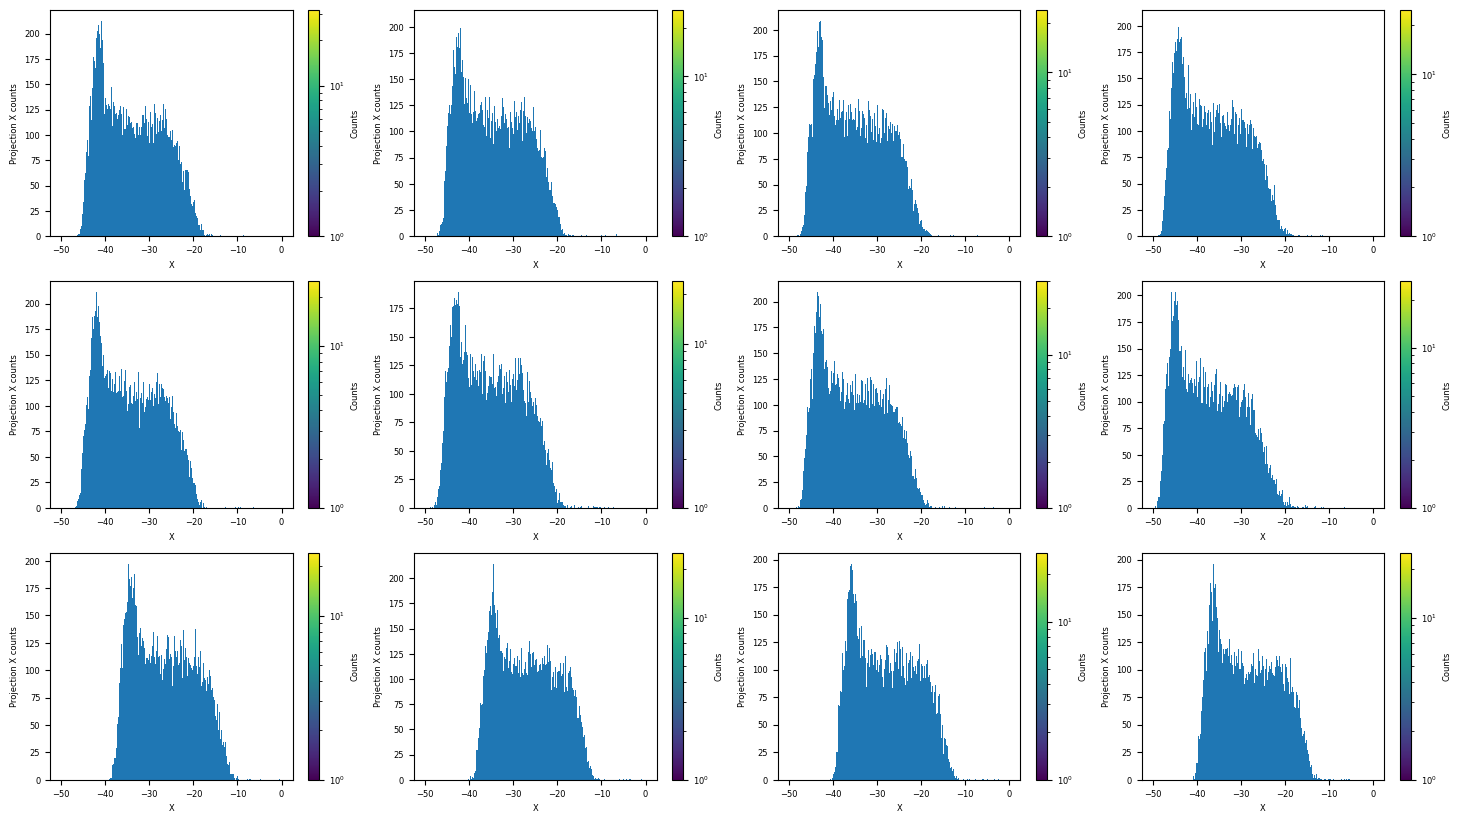

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from matplotlib import pyplot as plt
from hist.sparkHist2d import Hist2D
from hist.projection import ProjectionX
from matplotlib.colors import LogNorm


from make_MWDC_prm import drift_calib_data

#spark = SparkSession.builder.getOrCreate()
spark = SparkSession.builder.master("local[10]").getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

df = spark.read.parquet("/home/h487/data/parquet/run1027_mwdc.parquet")
runname = df.select("runname").collect()[0][0]

planes = ['dc31_x1','dc31_x2','dc31_y1','dc31_y2','dc31_x3','dc31_x4','dc31_y3','dc31_y4','dc32_x1','dc32_x2','dc32_y1','dc32_y2']
dc31_charge_range = [10,120]
dc31_timing_range = [-60,0]
dc32_charge_range = [10,120]
dc32_timing_range = [-60,0]

plt.figure(0, figsize=(18,10))
plt.rcParams["font.size"] = 6
for i, plane in enumerate(planes):
    q, mod = divmod(i,4)
    ax =plt.subplot2grid((3,4),(q,mod))
    dfp = df.select(f"{plane}_id",f"{plane}_charge",f"{plane}_timing")
    dfp = dfp.withColumn("charge0",F.expr(f"element_at({plane}_charge, 1)")) \
             .withColumn("timing0",F.expr(f"element_at({plane}_timing,1)")) \
             .withColumn("id0",F.expr(f"element_at({plane}_id, 1)")) \
             .filter("id0>0 and id0<15")

    if "dc31" in plane:
        charge_range = dc31_charge_range
        timing_range = dc31_timing_range
    else:
        charge_range = dc32_charge_range
        timing_range = dc32_timing_range
    dfp = dfp.filter(F.expr(f"charge0 > {charge_range[0]} and charge0 < {charge_range[1]} and timing0 > {timing_range[0]} and timing0 < {timing_range[1]}"))
    H, xedges, yedges = Hist2D(dfp, ["timing0","charge0"],[250,250],[[-50,0],[20,120]],  interpolation='none', norm=LogNorm())
    ax.clear()
    Hpr, xedges_pr = ProjectionX(H, xedges, yedges)
    print(xedges_pr[0],xedges_pr[-1],len(xedges_pr))
    drift_calib_data(Hpr, f"./prm/{plane}_drift_calib_data_{runname}.csv", h_range=(int(xedges_pr[0]), int(xedges_pr[-1])), nbin=len(xedges_pr)-1)
plt.show()